# Using PG-RAD as a module

This discusses the overall design of the code to understand how different parts interact, doing so by an interactive notebook demo. For specific usage of functions and classes, consult the API documentation in the side bar (relevant API documentation sections will also be hyperlinked in the below explanation).

## Imports

In [8]:
from matplotlib import pyplot as plt

from pg_rad.dataloader import load_data
from pg_rad.path import path_from_RT90
from pg_rad.landscape import Landscape
from pg_rad.sources import PointSource

from pg_rad.isotope import Isotope
from pg_rad.logger import setup_logger

setup_logger(log_level = "INFO")

In [9]:
FILENAME = "B10_NaIR_MGS_ROI_CPS_IPL.CSV"
df = load_data(FILENAME)

## Demo: Path regression

2026-01-28 15:53:22,182 - INFO: Piecewise regression reduced path from 105 to 4 segments.


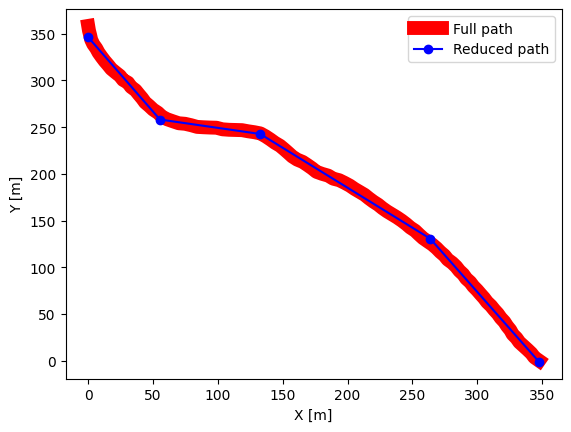

In [10]:
p1 = path_from_RT90(df, east_col = "East", north_col = "North", path_simplify = False)
p2 = path_from_RT90(df, east_col = "East", north_col = "North", path_simplify = True)

p1.plot(color='r', linestyle='-', linewidth = 10, label = "Full path")
p2.plot(color='b', linestyle='-', marker = 'o', label = "Reduced path")

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend()
plt.show()

## Landscape

The [Landscape](/API/landscape/landscape) is the starting point for the model. It is essentially an empty data structure which represents a cuboid space

$$
C = [0, x_{\max}] \times [0, y_{\max}] \times [0, z_{\max}] \subset \mathbb{R}^3
$$

where $x_{\max}, y_{\max}, z_{\max}$ are defined by the user upon creating the landscape object.

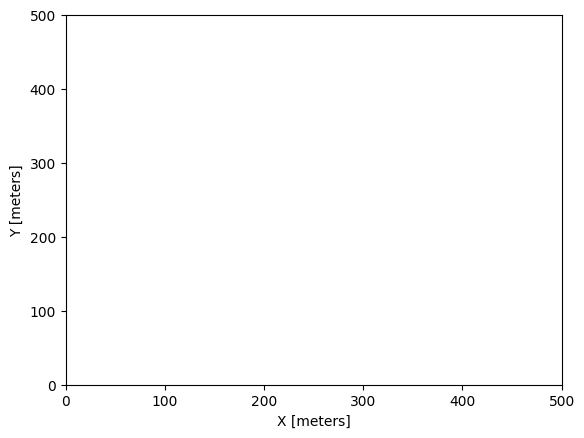

In [11]:
my_landscape = Landscape(size = (500, 500, 500), scale = 'meters')
fig, ax = my_landscape.plot()
plt.show()

Not much to see here, but we created the backbone of our simulation now.

## Point sources

A [PointSource](/API/sources/point_source) can be added to `my_landscape` in the following way:

In [12]:
cs137 = Isotope(name = "Cs137", E = 662.66, b = 0.851)
my_source = PointSource(x = 100, y = 100, z = 0, activity = 100, isotope = cs137)
my_landscape.add_sources(my_source)

my_landscape.sources

[PointSource(name=Source 2, pos=(100, 100, 0), isotope=Cs137, A=100 MBq)]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='X [meters]', ylabel='Y [meters]'>)

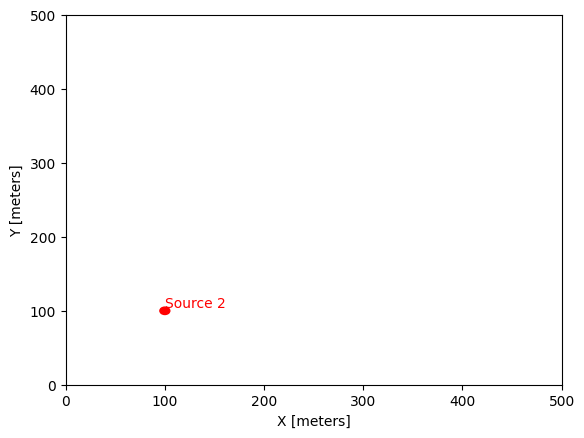

In [13]:
my_landscape.plot()

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='X [meters]', ylabel='Y [meters]'>)

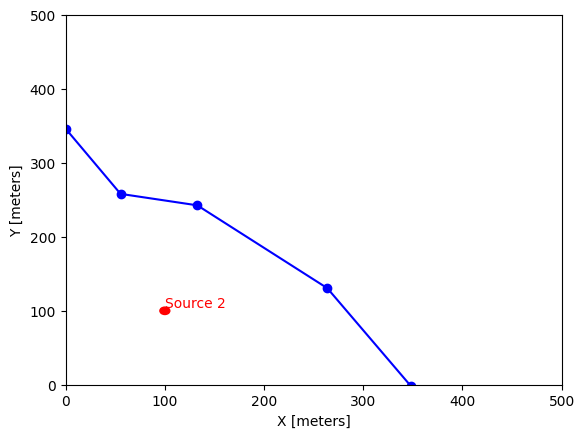

In [14]:
my_landscape.set_path(p2)
my_landscape.plot()